<a href="https://colab.research.google.com/github/aditisharma6244-ctrl/Sales-Forecasting/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
train = pd.read_csv("train.csv")
print(train.head())



   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0


In [ ]:
print(train.info())
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   year         int32         
 7   month        int32         
 8   day          int32         
 9   dayofweek    int32         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(3), object(1)
memory usage: 183.2+ MB
None
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
year           0
month          0
day            0
dayofweek      0
dtype: int64


In [ ]:
X = train[['store_nbr', 'onpromotion']]
y = train['sales']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(mean_squared_error(y_test, pred))

979090.527602773


In [ ]:
train['date'] = pd.to_datetime(train['date'])
train['month'] = train['date'].dt.month
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(rmse)

989.4900341098808


In [ ]:
print(r2_score(y_test, pred))

0.18256623467516941


In [ ]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['dayofweek'] = train['date'].dt.dayofweek

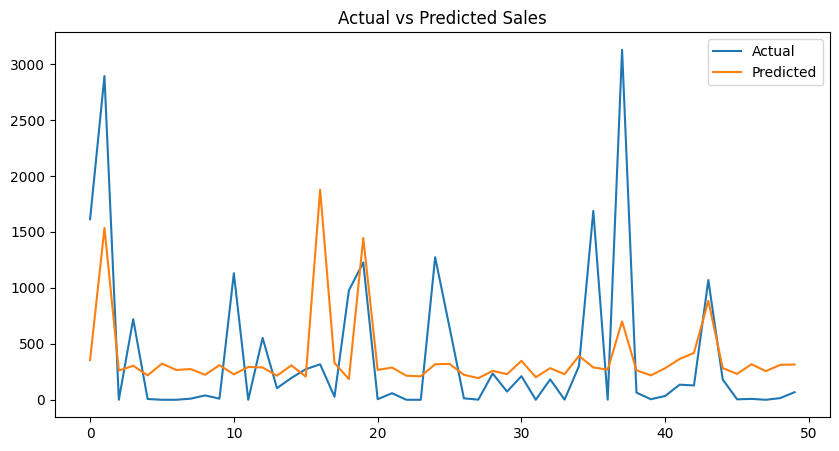

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

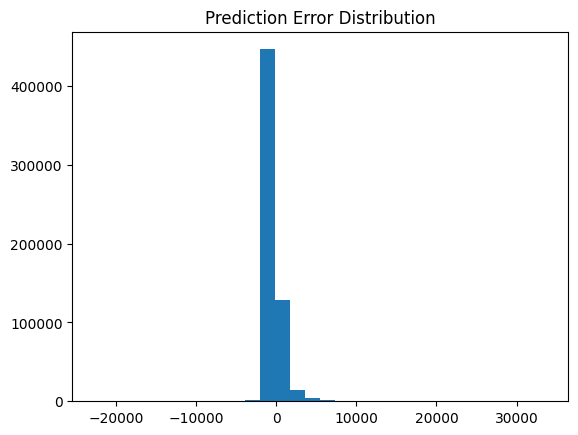

In [ ]:
errors = y_test - pred

plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.show()

In [ ]:
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, pred))

RMSE: 989.4900341098808
R2 Score: 0.18256623467516941
